# AOMIC-ID1000 - Tabular Phenotype Exploration

Target: **total intelligence** (`IST_intelligence_total`). This notebook profiles the
self-report phenotype that feeds the lower complexity tiers, with distributions,
missingness structure, correlation structure, associations with intelligence, and a
low-dimensional view of participants. Raw dataset values are shown here (before the
ontology projection and z-scoring done by the ingestion pipeline).

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
ROOT = Path.cwd().parent
IND = "#6366f1"; GRN = "#10b981"; ORG = "#f59e0b"; RED = "#ef4444"; BLU = "#38bdf8"

def _leaves(node):
    ch = node.get("children")
    if not ch:
        return [node]
    out = []
    for c in ch:
        out += _leaves(c)
    return out

def n_leaves(node):
    return len(_leaves(node))

def mm_leaves(node, out):
    # Collect every _leaves record from an arbitrary-depth multimodal tree.
    if isinstance(node, dict):
        for k, v in node.items():
            if k == "_leaves":
                out.extend(v)
            elif isinstance(v, dict):
                mm_leaves(v, out)

df = pd.read_csv(ROOT / "dataset" / "participants.tsv", sep="\t", na_values=["n/a","N/A",""])
manifest = json.load(open(ROOT / "ontology" / "feature_manifest.json"))
explore = json.load(open(ROOT / "ontology" / "exploration_report.json"))
target = manifest["target"]["column"]
tab = [p["column"] for p in manifest["predictors"] if not p["column"].startswith(("fs_","fc_"))]
tab_num = [p["column"] for p in manifest["predictors"]
           if p["stat_type"]=="numeric" and p["column"] in df.columns and not p["column"].startswith(("fs_","fc_"))]
print(len(df), "participants |", len(tab), "tabular predictors")

928 participants | 23 tabular predictors


## 1. Target and its subscales

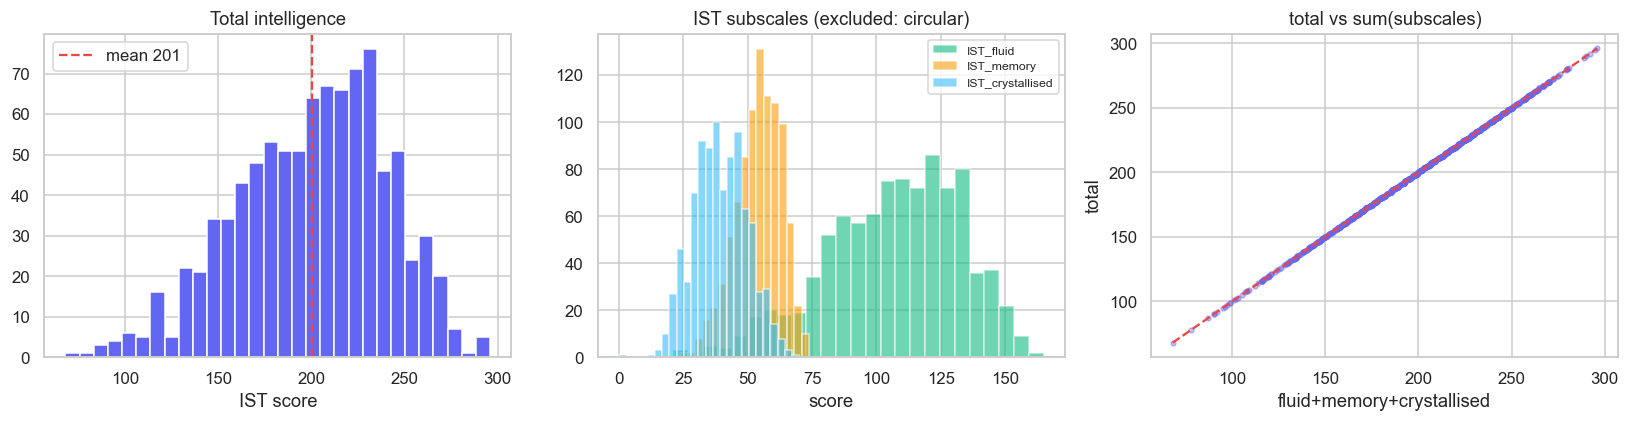

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
t = pd.to_numeric(df[target], errors="coerce")
ax[0].hist(t.dropna(), bins=30, color=IND, edgecolor="white")
ax[0].axvline(t.mean(), color=RED, ls="--", label=f"mean {t.mean():.0f}")
ax[0].set(title="Total intelligence", xlabel="IST score"); ax[0].legend()
for c, col in zip([GRN,ORG,BLU], ["IST_fluid","IST_memory","IST_crystallised"]):
    ax[1].hist(pd.to_numeric(df[col], errors="coerce").dropna(), bins=25, alpha=0.6, label=col, color=c)
ax[1].set(title="IST subscales (excluded: circular)", xlabel="score"); ax[1].legend(fontsize=8)
sub = df[["IST_fluid","IST_memory","IST_crystallised"]].apply(pd.to_numeric, errors="coerce").sum(axis=1)
ax[2].scatter(sub, t, s=10, alpha=0.4, color=IND)
ax[2].plot([t.min(),t.max()],[t.min(),t.max()], color=RED, ls="--")
ax[2].set(title="total vs sum(subscales)", xlabel="fluid+memory+crystallised", ylabel="total")
plt.tight_layout(); plt.show()

## 2. Coverage and missingness co-occurrence

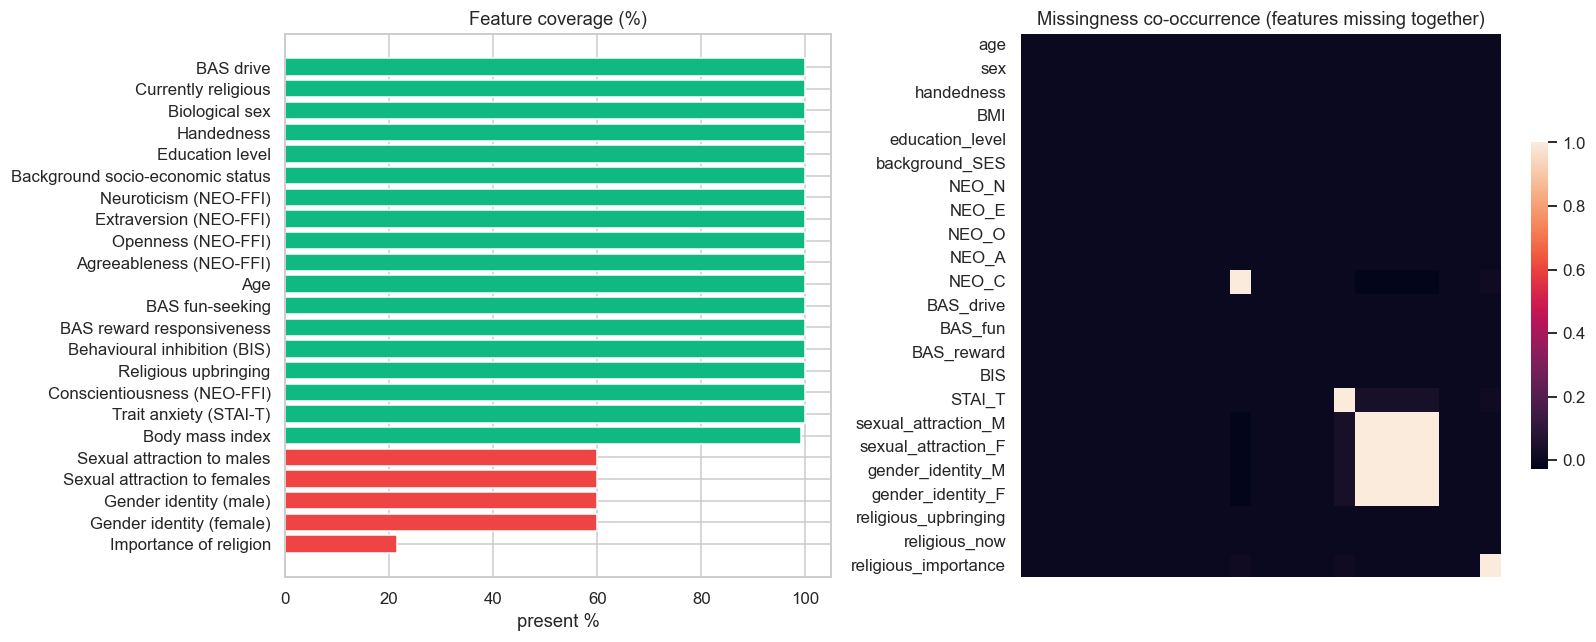

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios":[1,1.1]})
prof = pd.DataFrame(manifest["predictors"])
tt = prof[prof["column"].isin(tab)].sort_values("coverage_pct")
cols = [RED if c<70 else ORG if c<95 else GRN for c in tt["coverage_pct"]]
ax[0].barh(tt["label"], tt["coverage_pct"], color=cols)
ax[0].set(title="Feature coverage (%)", xlabel="present %")
miss = df[tab].isna().astype(int)
co = miss.corr().fillna(0)
sns.heatmap(co, cmap="rocket", ax=ax[1], cbar_kws={"shrink":.6}, xticklabels=False)
ax[1].set_title("Missingness co-occurrence (features missing together)")
plt.tight_layout(); plt.show()

## 3. Distributions of every self-report feature

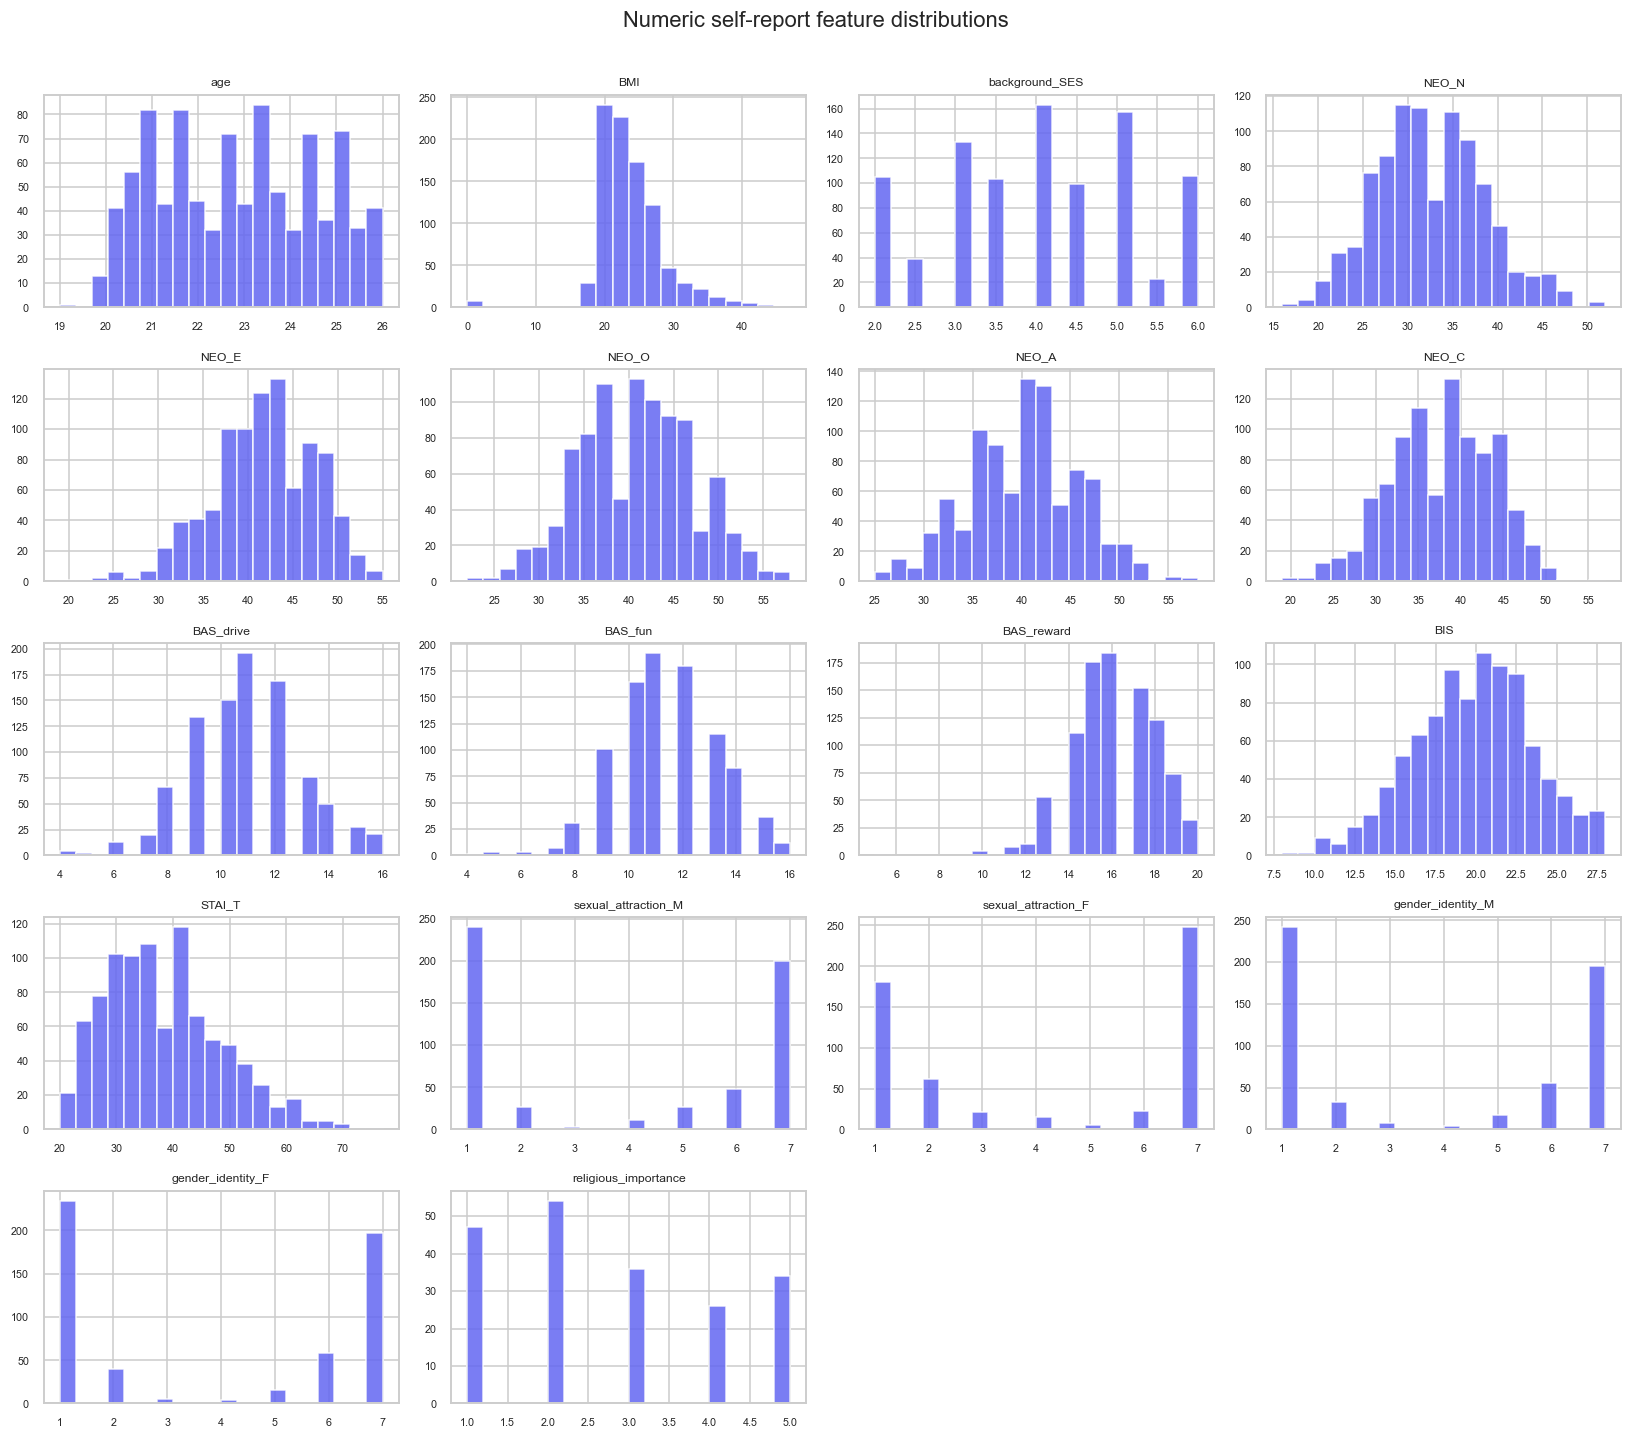

In [4]:
n = len(tab_num); ncol = 4; nrow = int(np.ceil(n/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.6*nrow))
for ax, c in zip(axes.flat, tab_num):
    v = pd.to_numeric(df[c], errors="coerce").dropna()
    ax.hist(v, bins=20, color=IND, edgecolor="white", alpha=0.85)
    ax.set_title(c, fontsize=8); ax.tick_params(labelsize=7)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.suptitle("Numeric self-report feature distributions", y=1.005); plt.tight_layout(); plt.show()

## 4. Categorical features

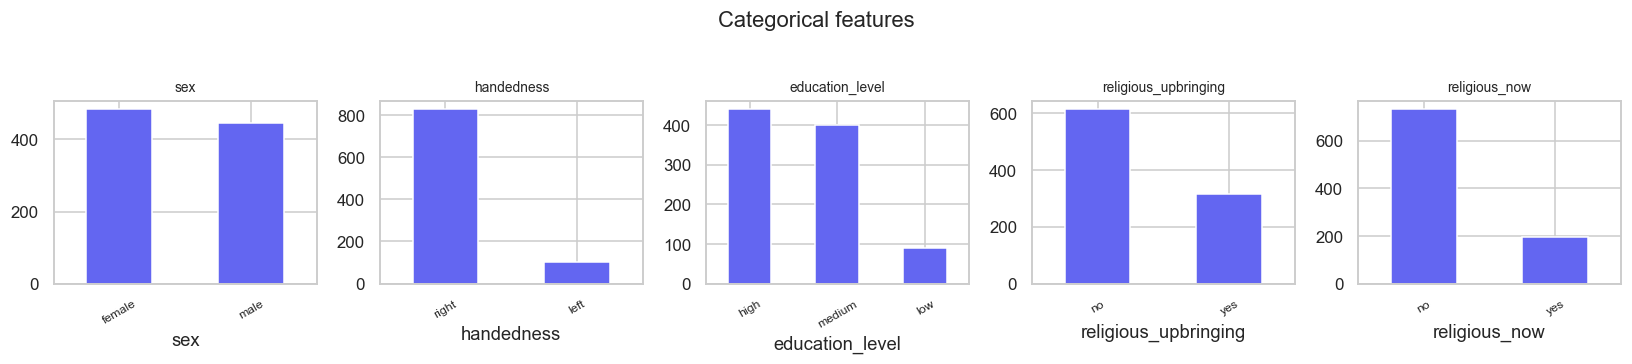

In [5]:
cats = [p["column"] for p in manifest["predictors"]
        if p["stat_type"] in ("binary","ordinal","nominal") and p["column"] in df.columns
        and not p["column"].startswith(("fs_","fc_"))]
fig, axes = plt.subplots(1, len(cats), figsize=(3*len(cats), 3.2))
for ax, c in zip(np.atleast_1d(axes), cats):
    df[c].astype(str).value_counts().plot(kind="bar", ax=ax, color=IND)
    ax.set_title(c, fontsize=9); ax.tick_params(axis="x", labelsize=8, rotation=30)
plt.suptitle("Categorical features", y=1.03); plt.tight_layout(); plt.show()

## 5. Correlation structure (clustered) and dendrogram\nThe intelligence target (`IST_intelligence_total`, highlighted in red) is included in the matrix, so the clustering places it next to the self-report features it correlates with most. The ranked list below reads off, directly from the data, which features most strongly predict intelligence.

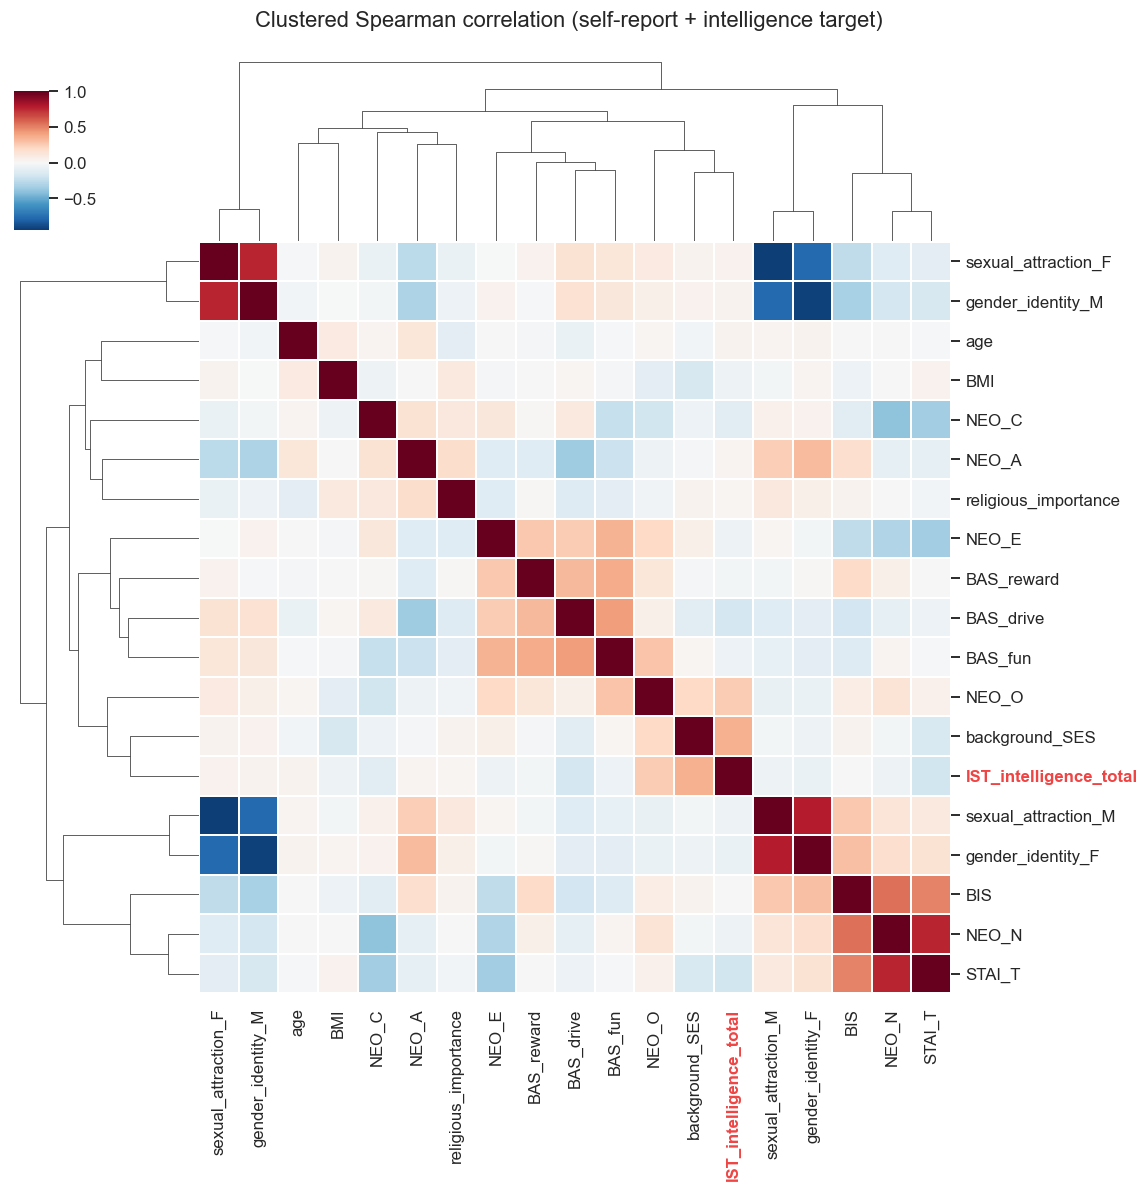

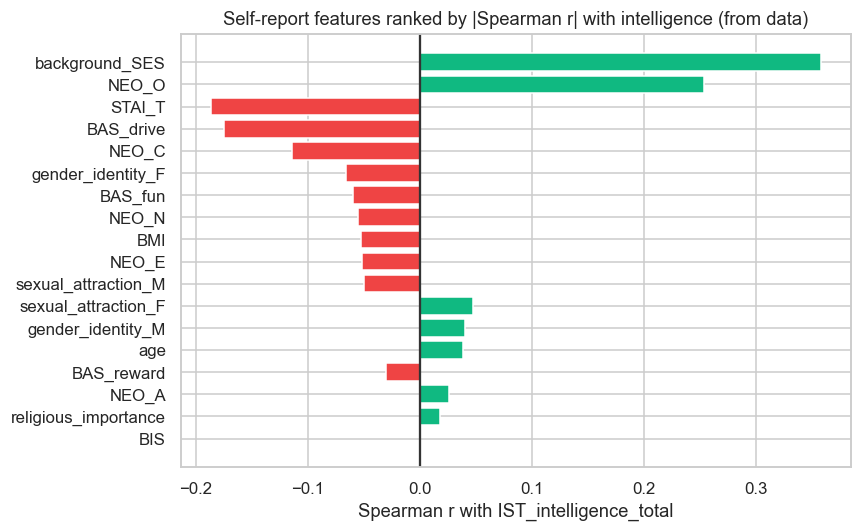

Spearman correlation with IST_intelligence_total (strongest first):
  +0.358  background_SES
  +0.254  NEO_O
  -0.186  STAI_T
  -0.174  BAS_drive
  -0.114  NEO_C
  -0.066  gender_identity_F
  -0.060  BAS_fun
  -0.055  NEO_N
  -0.052  BMI
  -0.052  NEO_E
  -0.050  sexual_attraction_M
  +0.048  sexual_attraction_F
  +0.040  gender_identity_M
  +0.039  age
  -0.030  BAS_reward
  +0.026  NEO_A
  +0.018  religious_importance
  +0.000  BIS


In [6]:
cols = tab_num + [target]
corr = df[cols].apply(pd.to_numeric, errors="coerce").corr(method="spearman")
try:
    g = sns.clustermap(corr, cmap="RdBu_r", center=0, figsize=(10.5,10.5), linewidths=.3,
                       cbar_pos=(0.02,0.83,0.03,0.12))
    g.fig.suptitle("Clustered Spearman correlation (self-report + intelligence target)", y=1.02)
    for tl in g.ax_heatmap.get_xticklabels() + g.ax_heatmap.get_yticklabels():
        if tl.get_text() == target:
            tl.set_color(RED); tl.set_fontweight("bold")
    plt.show()
except Exception as e:
    print("clustermap skipped:", e)
# Which self-report features most strongly predict intelligence, straight from the data?
tcorr = corr[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(tcorr.index[::-1], tcorr.values[::-1],
        color=[RED if v < 0 else GRN for v in tcorr.values[::-1]])
ax.axvline(0, color="#333")
ax.set(title="Self-report features ranked by |Spearman r| with intelligence (from data)",
       xlabel="Spearman r with IST_intelligence_total")
plt.tight_layout(); plt.show()
print("Spearman correlation with", target, "(strongest first):")
for f, r in tcorr.items():
    print(f"  {r:+.3f}  {f}")

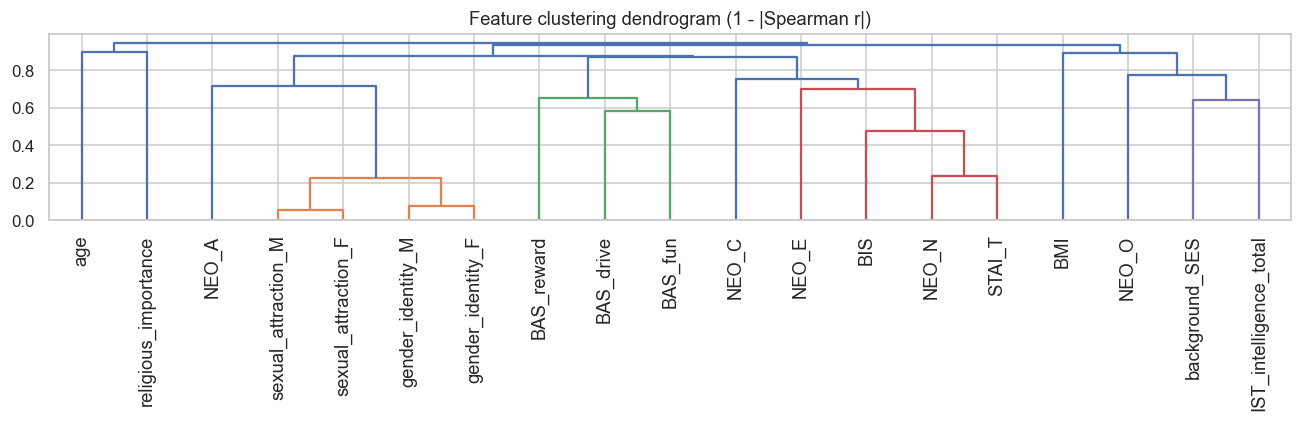

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
d = 1 - corr.abs().values; np.fill_diagonal(d,0); d=(d+d.T)/2
Z = linkage(squareform(d, checks=False), method="average")
fig, ax = plt.subplots(figsize=(12,4))
dendrogram(Z, labels=list(corr.columns), leaf_rotation=90, color_threshold=0.7, ax=ax)
ax.set_title("Feature clustering dendrogram (1 - |Spearman r|)"); plt.tight_layout(); plt.show()

## 6. What tracks intelligence?

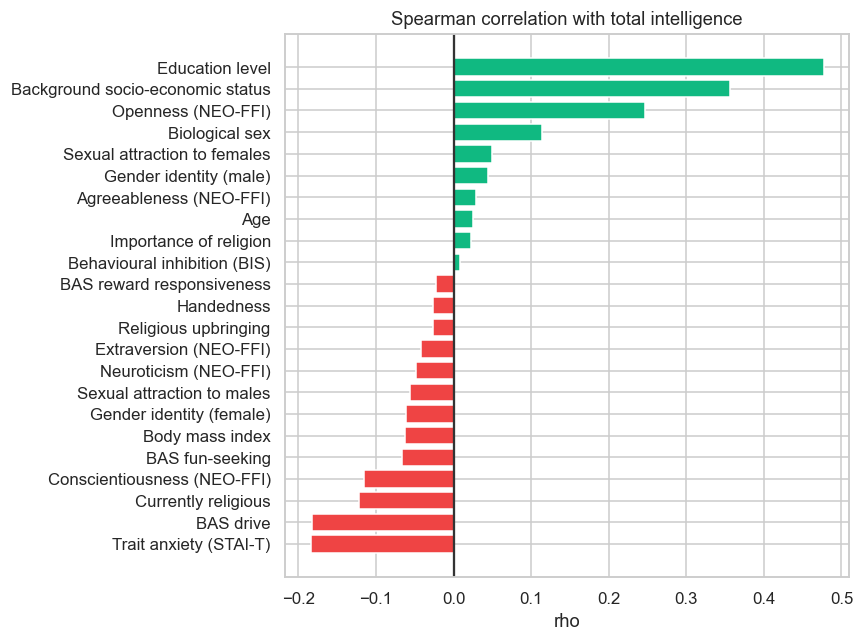

In [8]:
assoc = pd.DataFrame(explore.get("target_associations", []))
assoc = assoc[~assoc["feature"].str.startswith(("fs_","fc_"))].sort_values("spearman_r")
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(assoc["label"], assoc["spearman_r"], color=[RED if v<0 else GRN for v in assoc["spearman_r"]])
ax.axvline(0, color="#333"); ax.set(title="Spearman correlation with total intelligence", xlabel="rho")
plt.tight_layout(); plt.show()

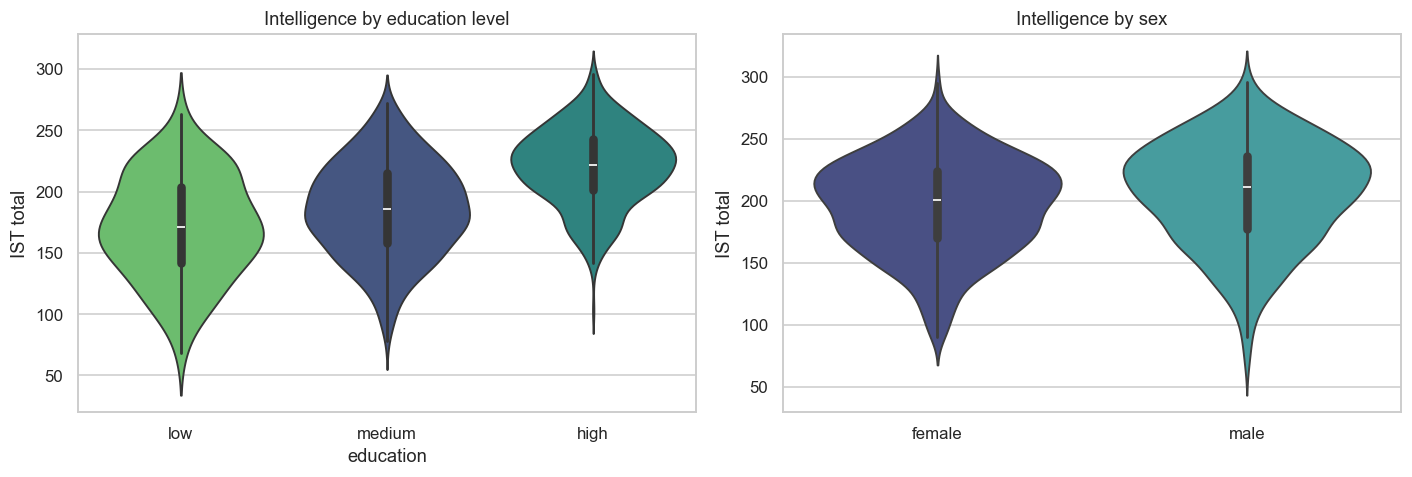

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
order = ["low","medium","high"]
sns.violinplot(data=df.assign(_t=pd.to_numeric(df[target],errors="coerce")),
               x="education_level", y="_t", order=order, ax=ax[0], hue="education_level",
               palette="viridis", legend=False)
ax[0].set(title="Intelligence by education level", xlabel="education", ylabel="IST total")
sns.violinplot(data=df.assign(_t=pd.to_numeric(df[target],errors="coerce")),
               x="sex", y="_t", ax=ax[1], hue="sex", palette="mako", legend=False)
ax[1].set(title="Intelligence by sex", xlabel="", ylabel="IST total")
plt.tight_layout(); plt.show()

## 7. Top associates and a participant embedding

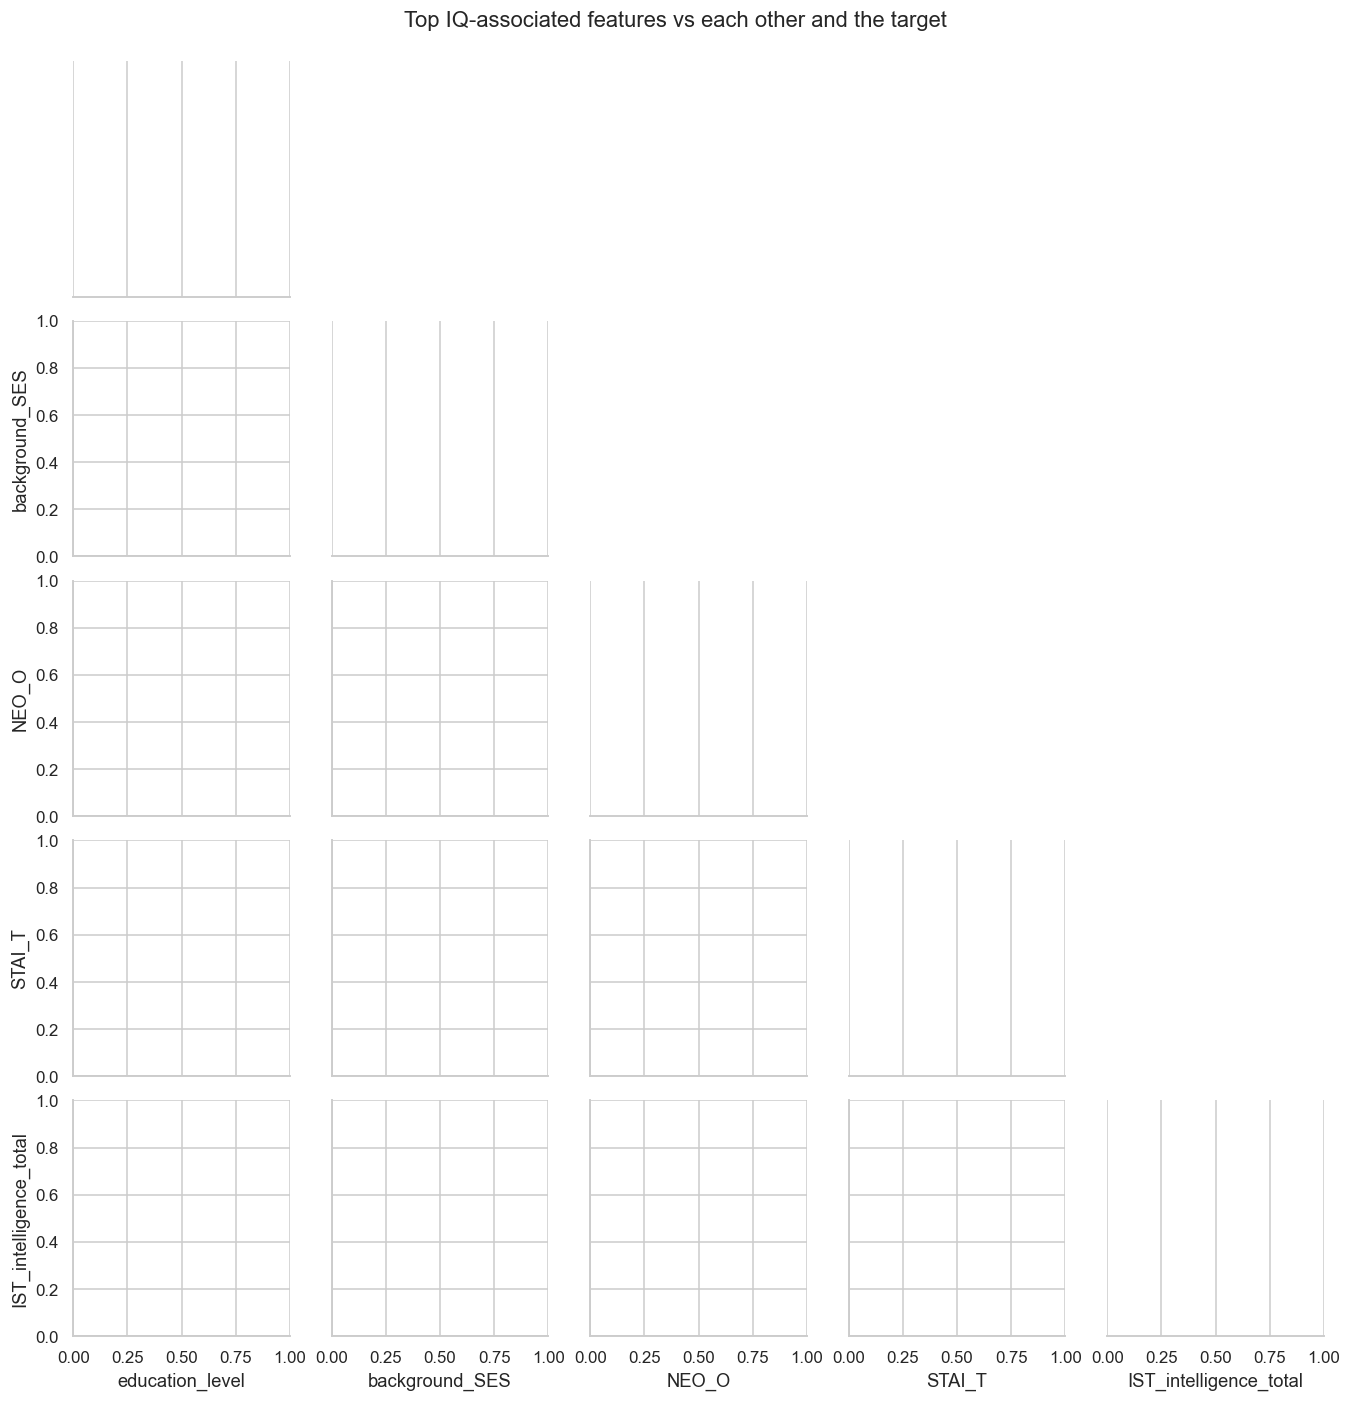

In [10]:
top = assoc.reindex(assoc["spearman_r"].abs().sort_values(ascending=False).index)["feature"].head(4).tolist()
pair = df[top + [target]].apply(pd.to_numeric, errors="coerce").dropna()
g = sns.pairplot(pair, corner=True, plot_kws={"s":8,"alpha":0.4,"color":IND}, diag_kws={"color":IND})
g.fig.suptitle("Top IQ-associated features vs each other and the target", y=1.02); plt.show()

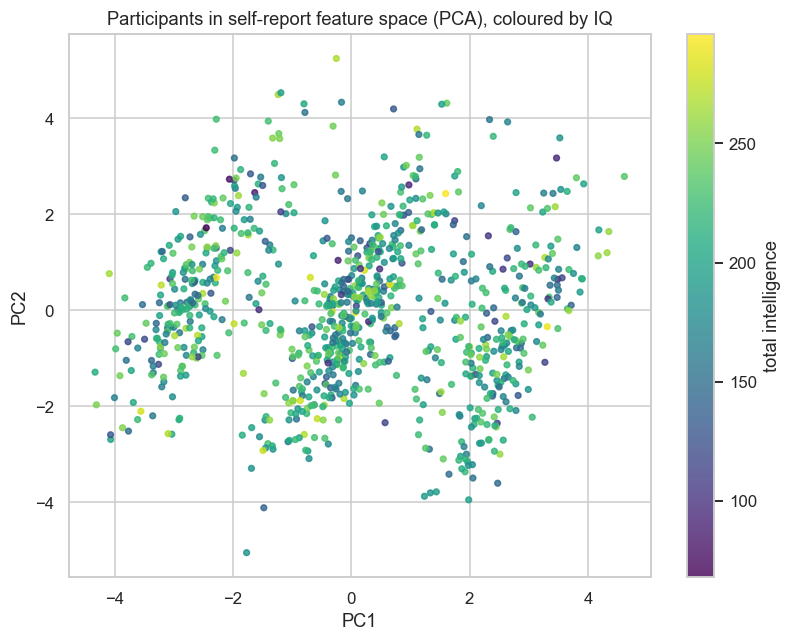

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X = df[tab_num].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean())
Z2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
fig, ax = plt.subplots(figsize=(7.5,6))
sc = ax.scatter(Z2[:,0], Z2[:,1], c=pd.to_numeric(df[target],errors="coerce"), cmap="viridis", s=14, alpha=0.8)
plt.colorbar(sc, label="total intelligence")
ax.set(title="Participants in self-report feature space (PCA), coloured by IQ",
       xlabel="PC1", ylabel="PC2")
plt.tight_layout(); plt.show()

Personality and education carry the strongest (still weak) individual signals; no single feature separates high from low intelligence, which is why the engine is asked to recover a ranking from the whole multi-modal profile.